## Part_E_regression

In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
# Load Data
fact_channel = pd.read_csv("../data/fact_channel_daily.csv")
fact_channel["date"] = pd.to_datetime(fact_channel["date"])

fact_channel.head()

,date,channel,total_spend,attributed_orders,attributed_revenue,day_of_week,promo_flag,week_index
0,2025-07-04,email,19566.32,20.0,123248.30,Friday,1,0
1,2025-07-04,organic,5380.51,14.0,64098.51,Friday,1,0
2,2025-07-04,paid_social,157932.61,30.0,152446.28,Friday,1,0
3,2025-07-04,referral,32210.79,6.0,37622.67,Friday,1,0
4,2025-07-04,search,188257.71,43.0,243962.18,Friday,1,0


In [9]:
# Pivot spend
spend_wide = fact_channel.pivot_table(
    index="date",
    columns="channel",
    values="total_spend",
    aggfunc="sum",
    fill_value=0
)

spend_wide.columns = [f"{c}_spend" for c in spend_wide.columns]
spend_wide = spend_wide.reset_index()

# Daily revenue
daily_target = fact_channel.groupby("date", as_index=False).agg(
    daily_revenue=("attributed_revenue", "sum"),
    promo_flag=("promo_flag", "max")
)

# Merge
model_df = spend_wide.merge(daily_target, on="date")

model_df.head()

,date,email_spend,organic_spend,paid_social_spend,referral_spend,search_spend,daily_revenue,promo_flag
0,2025-07-04,19566.32,5380.51,157932.61,32210.79,188257.71,621377.94,1
1,2025-07-05,18352.15,4010.76,130147.97,32529.45,159676.14,418793.94,0
2,2025-07-06,17708.52,4565.21,126196.48,29244.95,164394.80,378668.50,0
3,2025-07-07,16110.20,3856.91,117923.28,29280.44,142097.27,542583.45,0
4,2025-07-08,16823.84,3983.43,112896.66,28023.88,164299.43,487601.84,0


In [10]:
# Add Features
model_df["trend"] = np.arange(len(model_df))
model_df["day_of_week"] = model_df["date"].dt.day_name()

# One-hot encoding
dow = pd.get_dummies(model_df["day_of_week"], drop_first=True)
model_df = pd.concat([model_df, dow], axis=1)

In [11]:
# Model Setup
spend_cols = [c for c in model_df.columns if "_spend" in c]

features = spend_cols + ["promo_flag", "trend"] + list(dow.columns)

X = model_df[features]
y = model_df["daily_revenue"]

In [14]:
# Train/Test Split
split = int(len(model_df) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [15]:
# Train Model.
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [16]:
# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 70339.32523882332
RMSE: 96857.97646422882
R2: 0.28272872271221583


In [17]:
# Coefficients
coef_df = pd.DataFrame({
    "feature": features,
    "coef": model.coef_
}).sort_values("coef", ascending=False)

coef_df

,feature,coef
5,promo_flag,153330.204320
8,Saturday,30487.645405
9,Sunday,7252.913871
6,trend,463.785249
3,referral_spend,1.648361
2,paid_social_spend,0.860182
4,search_spend,0.490580
0,email_spend,-10.432716
1,organic_spend,-20.924757
7,Monday,-12663.335770


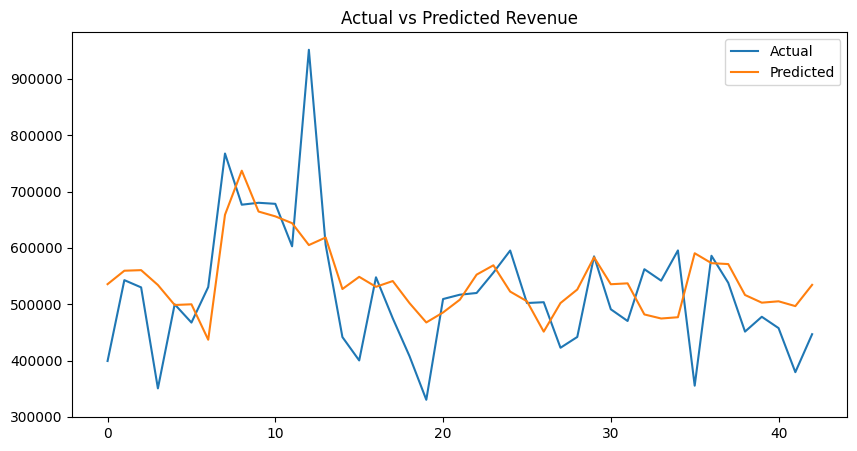

In [18]:
# Plot

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Revenue")
plt.show()

### Interpretation

Referral shows the highest marginal impact on revenue, followed by Paid Social and Search. These channels have positive coefficients, indicating that increases in spend are associated with increases in revenue.

Email and Organic show negative coefficients, which are likely driven by multicollinearity, attribution overlap, or model limitations rather than true negative impact.

The model has a relatively low R², indicating that a significant portion of revenue variation is not explained by the included variables. Therefore, the results should be interpreted as directional insights rather than precise causal estimates.

### Limitations


The model measures association, not causation, has moderate explanatory power, and may be affected by multicollinearity, omitted variables, attribution assumptions, and linearity constraints.